In [1]:
import pandas as pd
import numpy as np
from scipy import signal 
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(rc={'figure.figsize':(16,9)})

In [49]:
filepath="/home/pi/Desktop/RaspberryPi_Dev/Bluetooth/Sheet_D_Medium_Thin_28012022_1408.csv"
ecg_data=pd.read_csv(filepath)

In [50]:
col_names=ecg_data.columns
ecg_data=ecg_data.rename(columns={col_names[0]:'tstamps',col_names[1]:'CH1_Data',col_names[2]:'CH2_Data',col_names[3]:'CH3_Data'})

Text(0.5, 1.0, 'Full recorded data (Approx 3 min)')

<Figure size 1152x648 with 0 Axes>

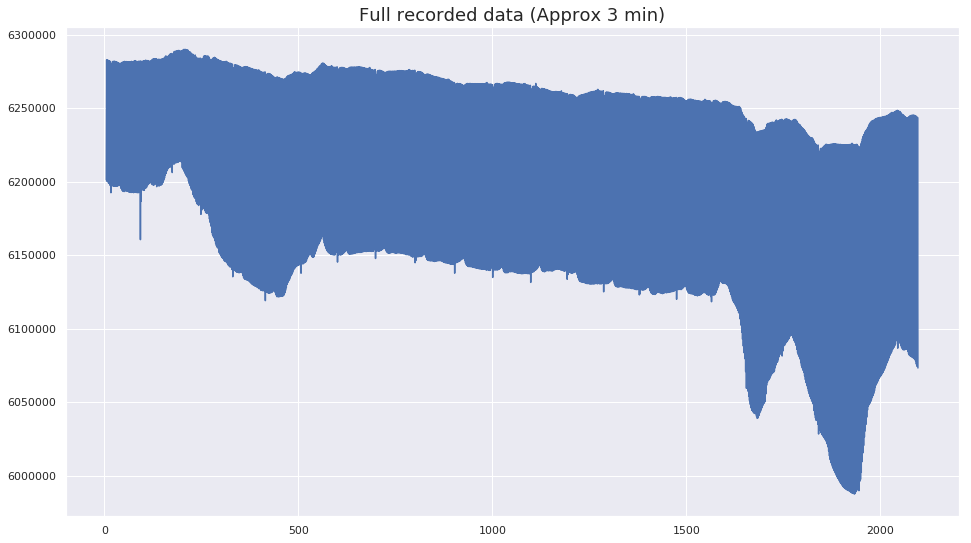

In [51]:
plt.figure('ECG from Hip plot (Measured on 10th Dec 2021)') # All data
fig, ax=plt.subplots()
plt.plot(ecg_data['CH1_Data'][5:])
plt.title('Full recorded data (Approx 3 min)', fontsize=18)
# ax.annotate('Standing still',(2500,4125000), fontsize=16, bbox=dict(boxstyle="darrow,pad=0.2", fc="yellow", ec="k", lw=1))
# ax.annotate('High knees',(9450,4140000), fontsize=16, bbox=dict(boxstyle="darrow,pad=0.2", fc="cyan", ec="k", lw=1))
# ax.annotate('On the spot jogging',(12500,4100000), fontsize=16, bbox=dict(boxstyle="darrow,pad=0.2", fc="white", ec="k", lw=1))

Text(0.5, 1.0, 'On the spot jogging')

<Figure size 1152x648 with 0 Axes>

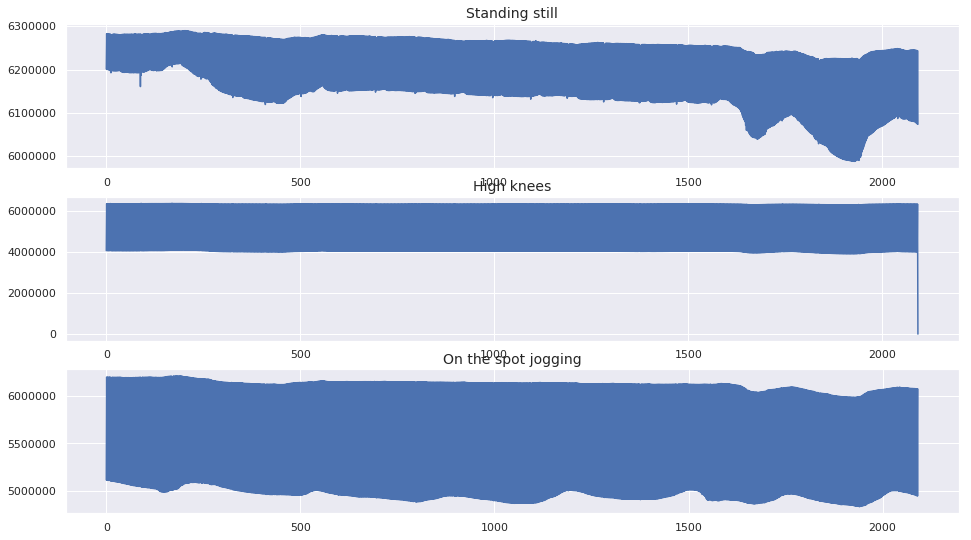

In [56]:
# Separating data recorded during different activitites
CH1_Data=np.array(ecg_data.iloc[0:]['CH1_Data'][5:])
CH2_Data=np.array(ecg_data.iloc[0:]['CH2_Data'][5:])
CH3_Data=np.array(ecg_data.iloc[0:]['CH3_Data'][5:])

plt.figure('ECG from Hip plot (Measured on 10th Dec 2021)') # All data
fig, ax=plt.subplots()

plt.subplot(311)
plt.plot(CH1_Data)
plt.title('Standing still', fontsize=14)
plt.subplot(312)
plt.plot(CH2_Data)
plt.title('High knees', fontsize=14)
plt.subplot(313)
plt.plot(CH3_Data)
plt.title('On the spot jogging', fontsize=14)

Text(0.5, 0, 'Sample points')

<Figure size 1152x648 with 0 Axes>

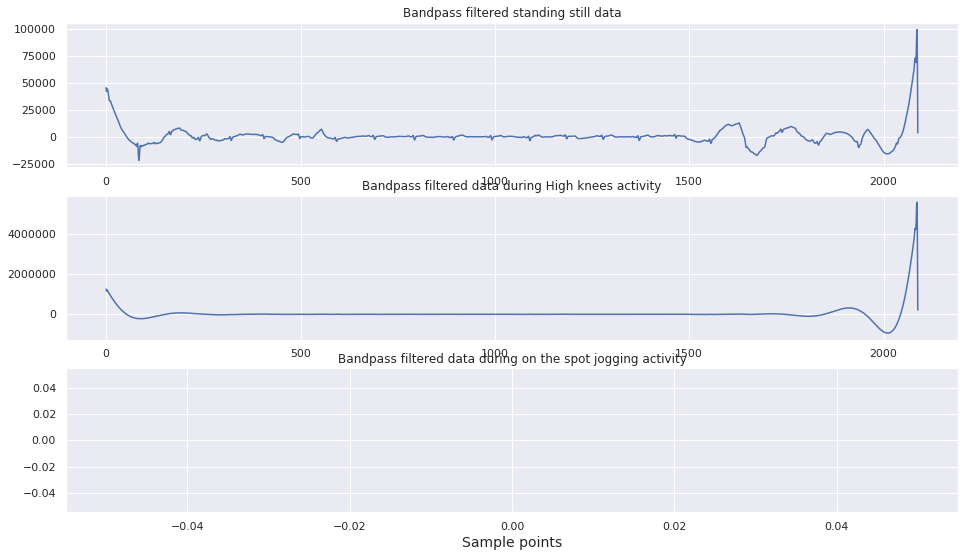

In [59]:
b, a = signal.butter(4, [0.5, 20], btype='bandpass', fs=100)

plt.figure('Filtered ECG data from measured from Hip area') # All data
fig, ax=plt.subplots()

plt.subplot(311)
fil_CH1_Data = signal.filtfilt(b, a, CH1_Data)
plt.plot(fil_CH1_Data[4:])
plt.title('Bandpass filtered standing still data',fontsize=12)

plt.subplot(312)
fil_CH2_Data = signal.filtfilt(b, a, CH2_Data)
plt.plot(fil_CH2_Data[4:])
plt.title('Bandpass filtered data during High knees activity',fontsize=12)

plt.subplot(313)
fil_CH3_Data = signal.filtfilt(b, a, CH3_Data)
plt.plot(fil_CH3_Data[4:])
plt.title('Bandpass filtered data during on the spot jogging activity',fontsize=12)

plt.xlabel('Sample points',fontsize=14)

In [60]:
# Estimate power spectral density
f,pxx1=signal.welch(CH1_Data,fs=100.,window='hann', nperseg=2**9, noverlap=2**8, detrend='constant')
f,pxx2=signal.welch(CH2_Data,fs=100., window='hann', nperseg=2**9, noverlap=2**8, detrend='constant')
f,pxx3=signal.welch(CH3_Data,fs=100., window='hann', nperseg=2**9, noverlap=2**8, detrend='constant')

Text(0.5, 0, 'Frequency (Hz)')

<Figure size 1152x648 with 0 Axes>

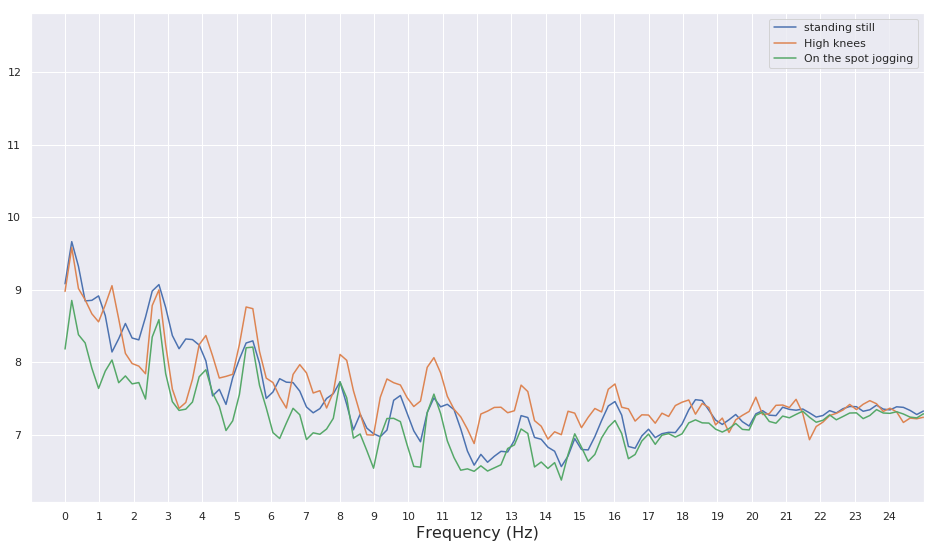

In [32]:
# Plot power spectral densities
plt.figure('Filtered ECG data from measured from Hip area') # All data
fig, ax=plt.subplots()
plt.xticks([i for i in range(25)])
plt.xlim([-1,25])

plt.plot(f,np.log10(pxx1))
plt.plot(f,np.log10(pxx2))
plt.plot(f,np.log10(pxx3))
plt.legend(['standing still','High knees','On the spot jogging'])
plt.xlabel('Frequency (Hz)', fontsize=16)